In [126]:
from typing import List, Dict
from copy import deepcopy
from functools import partial
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import pyscf
from openfermion import MolecularData
from openfermion.chem import geometry_from_pubchem
from openfermionpyscf import run_pyscf
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.primitives import BitArray
from qiskit_aer import AerSimulator  # For MPS Simulator.
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import qiskit_ibm_runtime
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_addon_sqd.fermion import SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch
import ffsim
from adaptvqe.pools import DVE_CEO, FullPauliPool
from adaptvqe.algorithms.adapt_vqe import TensorNetAdapt
from remove_idle import remove_idle, merge_idle_bits

In [62]:
# Get molecular integrals
mol = pyscf.gto.Mole()
geom = geometry_from_pubchem("LiH")
basis = "sto-3g"
symmetry = "C1"
multiplicity = 1
charge = 0
mol.build(
    atom=geom,
    basis=basis,
    symmetry=symmetry,
)
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())
scf = pyscf.scf.RHF(mol).run()
num_orbitals = len(active_space)
print(f"Molecule has {num_orbitals} orbitals.")
n_electrons = int(sum(scf.mo_occ[active_space]))
num_elec_a = (n_electrons + mol.spin) // 2
num_elec_b = (n_electrons - mol.spin) // 2
nelec = (num_elec_a, num_elec_b)
cas = pyscf.mcscf.CASCI(scf, num_orbitals, (num_elec_a, num_elec_b))
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)

converged SCF energy = -7.76736213574856
Molecule has 6 orbitals.


In [63]:
geom = geometry_from_pubchem("lih")
basis = 'sto-3g'
multiplicity = 1
charge = 0
mol = MolecularData(geom, basis, multiplicity, charge, description='mol')
mol = run_pyscf(mol, run_fci=True, run_ccsd=True)

In [64]:
exact_energy = mol.fci_energy
print(f"exact energy = {exact_energy}")

exact energy = -7.784460280031223


In [65]:
pool = DVE_CEO(mol)
# pool = FullPauliPool(molecule)

my_adapt = TensorNetAdapt(
    pool=pool,
    molecule=mol,
    max_adapt_iter=3,
    recycle_hessian=True,
    tetris=True,
    verbose=True,
    threshold=0.1,
)

my_adapt.run()
data = my_adapt.data


tensor-net-adapt prepared with the following settings:
> Pool: DVE_CEO
> Molecule: mol (interatomic distance r=0Å)
> Orbital Optimization: False
> Selection method: gradient
> Convergence criterion: total_g_norm
> Recycling Hessian: True
> Tetris: True (progressive optimization: False)
> Convergence threshold (gradient norm):  0.1
> Maximum number of iterations:  3
> Candidates per iteration:  1
> Swap-based circuits for LNN connectivity:  False
> Qiskit-transpiler-based circuits for LNN connectivity:  False

Initial energy: -7.767362135767289

*** ADAPT-VQE Iteration 1 ***

Creating list of up to 1200 operators ordered by gradient magnitude...

Non-Zero Gradients (tolerance E-8):
Operator 1: 2.3498754872786927e-05
Operator 4: -3.579000742959405e-05
Operator 6: -2.3498754859312313e-05
Operator 9: 3.579000742846925e-05
Operator 10: 7.757420088575967e-05
Operator 13: -0.00011829956413717511
Operator 14: -7.757420077702607e-05
Operator 17: 0.00011829956338935558
Operator 48: 0.0389182268

/Users/benjamindalfavero/.venv/adapt/lib/python3.13/site-packages/quimb/tensor/circuit.py:215: SyntaxWarning: Unsupported operation ignored: barrier
  warnings.warn(
/Users/benjamindalfavero/.venv/adapt/lib/python3.13/site-packages/quimb/tensor/circuit.py:215: SyntaxWarning: Unsupported operation ignored: barrier
  warnings.warn(
/Users/benjamindalfavero/Documents/phd/wellcome/ceo-adapt-vqe/adaptvqe/algorithms/adapt_vqe.py:2551: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  opt_result = minimize_bfgs(
/Users/benjamindalfavero/Documents/phd/wellcome/ceo-adapt-vqe/adaptvqe/algorithms/adapt_vqe.py:2566: UserWarning: Optimizer did not succeed. Message: Desired error not necessarily achieved due to precision loss.
  warn(f"Optimizer did not succeed. Message: {opt_result.message}")
/Users/benjamindalfavero/.venv/adapt/lib/python3.13/site-packages/quimb/tensor/circuit.py:215: SyntaxWarning: Unsupported operation ignored: barrier
  warnings.warn(


         Current function value: -7.767362
         Iterations: 0
         Function evaluations: 31
         Gradient evaluations: 19
Energy change:  -0.009689469609534207
Operator(s) added to ansatz: [971 588]
Gradients: [np.float64(2.3495094758629875e-14)]

Screening operators with disjoint supports...
None found.


Current energy: -7.7770516053768235
(change of -0.009689469609534207)
Current ansatz: [np.int64(971), np.int64(588)]

*** ADAPT-VQE Iteration 2 ***

Creating list of up to 1200 operators ordered by gradient magnitude...

Non-Zero Gradients (tolerance E-8):
Operator 0: 0.0009573747153837486
Operator 1: 0.00010852413113556614
Operator 4: 0.0013348328924457187
Operator 5: -0.0009573747153838179
Operator 6: -0.00010852413112214391
Operator 9: -0.0013348328924463893
Operator 10: 0.0032435114130776347
Operator 13: 0.0003298083025839797
Operator 14: -0.003243511412968518
Operator 17: -0.0003298083034314572
Operator 20: 0.003331433357624907
Operator 23: -0.0033314333576245155
Ope

/Users/benjamindalfavero/.venv/adapt/lib/python3.13/site-packages/quimb/tensor/circuit.py:215: SyntaxWarning: Unsupported operation ignored: barrier
  warnings.warn(
/Users/benjamindalfavero/Documents/phd/wellcome/ceo-adapt-vqe/adaptvqe/algorithms/adapt_vqe.py:2551: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  opt_result = minimize_bfgs(
/Users/benjamindalfavero/Documents/phd/wellcome/ceo-adapt-vqe/adaptvqe/algorithms/adapt_vqe.py:2566: UserWarning: Optimizer did not succeed. Message: Desired error not necessarily achieved due to precision loss.
  warn(f"Optimizer did not succeed. Message: {opt_result.message}")
/Users/benjamindalfavero/.venv/adapt/lib/python3.13/site-packages/quimb/tensor/circuit.py:215: SyntaxWarning: Unsupported operation ignored: barrier
  warnings.warn(


         Current function value: -7.779492
         Iterations: 5
         Function evaluations: 53
         Gradient evaluations: 41
Energy change:  -0.0024400776254296375
Operator(s) added to ansatz: [971 588]
Gradients: [np.float64(0.0010536231125588158)]

Screening operators with disjoint supports...
None found.


Current energy: -7.779491683002253
(change of -0.0024400776254296375)
Current ansatz: [np.int64(971), np.int64(588), np.int64(971), np.int64(588)]

*** ADAPT-VQE Iteration 3 ***

Creating list of up to 1200 operators ordered by gradient magnitude...

Non-Zero Gradients (tolerance E-8):
Operator 0: 0.0017658865556826949
Operator 1: -0.0007093902114518323
Operator 4: 0.0023629063948794327
Operator 5: -0.0017658865556829297
Operator 6: 0.0007093902114653759
Operator 9: -0.00236290639487973
Operator 10: 0.005812925672859213
Operator 13: 0.0006398972154708507
Operator 14: -0.005812925672750139
Operator 17: -0.0006398972163975616
Operator 20: 0.006094190722853956
Operator 23: -

/Users/benjamindalfavero/.venv/adapt/lib/python3.13/site-packages/quimb/tensor/circuit.py:215: SyntaxWarning: Unsupported operation ignored: barrier
  warnings.warn(
/Users/benjamindalfavero/Documents/phd/wellcome/ceo-adapt-vqe/adaptvqe/algorithms/adapt_vqe.py:2551: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  opt_result = minimize_bfgs(
/Users/benjamindalfavero/Documents/phd/wellcome/ceo-adapt-vqe/adaptvqe/algorithms/adapt_vqe.py:2566: UserWarning: Optimizer did not succeed. Message: Desired error not necessarily achieved due to precision loss.
  warn(f"Optimizer did not succeed. Message: {opt_result.message}")
/Users/benjamindalfavero/.venv/adapt/lib/python3.13/site-packages/quimb/tensor/circuit.py:215: SyntaxWarning: Unsupported operation ignored: barrier
  warnings.warn(


         Current function value: -7.780223
         Iterations: 1
         Function evaluations: 50
         Gradient evaluations: 38
Energy change:  -0.0007309490492586335
Operator(s) added to ansatz: [946 602]
Gradients: [np.float64(-0.0022570634167217623)]

Screening operators with disjoint supports...
None found.


Current energy: -7.780222632051512
(change of -0.0007309490492586335)
Current ansatz: [np.int64(971), np.int64(588), np.int64(971), np.int64(588), np.int64(946), np.int64(602)]
Performing final convergence check...
Total gradient norm: 0.2208264056070105

The maximum number of iterations (3) was hit before the convergence criterion was satisfied.
(current gradient norm is 0.2377223585759546 > 0.1)


In [66]:
ckt = data.get_circuit(pool, my_adapt.indices, my_adapt.coefficients, include_ref=True)

In [67]:
idle_qubit_bools, ckt_no_idle = remove_idle(ckt)
num_idle = len(idle_qubit_bools)
print(f"Removed {num_idle} idle qubits out of {ckt.num_qubits}.")
print(idle_qubit_bools)

Removed 2 idle qubits out of 12.
{2: False, 3: False}


In [68]:
idle_qubit_indices = sorted(list(idle_qubit_bools.keys()))
all_qubit_indices = sorted([q._index for q in ckt.qubits])
active_qubit_indices = list(set(all_qubit_indices) - set(idle_qubit_indices))
active_qubit_indices = sorted(active_qubit_indices)
print(f"Active qubits: {active_qubit_indices}")
print(f"Idle qubits: {idle_qubit_indices}")

Active qubits: [0, 1, 4, 5, 6, 7, 8, 9, 10, 11]
Idle qubits: [2, 3]


In [69]:
ckt.measure_all()
ckt_no_idle.measure_all()

In [132]:
simulator = AerSimulator(method="matrix_product_state")
result_idle = simulator.run(ckt).result()
counts_idle = result_idle.get_counts(0)
print(counts_idle)
result_no_idle = simulator.run(ckt_no_idle).result()
counts_no_idle = result_no_idle.get_counts(0)
print(counts_no_idle)

{'110000000011': 11, '110010000001': 7, '111100000000': 1006}
{'1100100001': 5, '1100000011': 15, '1111000000': 1004}


In [133]:
def insert_fixed_bools_into_bit_array(active_qubit_indices: List[int], bit_array: BitArray, idle_bools: Dict[int, bool]) -> BitArray:
    """Insert the idle booleans into a bit array."""

    bool_array = bit_array.to_bool_array()
    bool_array_flipped = np.flip(bool_array, 1)
    bool_array_inserted = merge_idle_bits(active_qubit_indices, bool_array_flipped, idle_bools)
    bool_array_inserted_flipped = np.flip(bool_array_inserted, 1)
    return BitArray.from_bool_array(bool_array_inserted_flipped)

In [134]:
bit_array_idle = BitArray.from_counts(counts_idle)
bit_array_no_idle = BitArray.from_counts(counts_no_idle)

In [135]:
bit_array_no_idle_inserted = insert_fixed_bools_into_bit_array(active_qubit_indices, bit_array_no_idle, idle_qubit_bools)
bool_array_no_idle = bit_array_idle.to_bool_array()
bool_array_idle = bit_array_no_idle_inserted.to_bool_array()

In [136]:
def bool_list_to_int(bool_list: List[bool]) -> int:
    """Convert a list of boolean to an int,
    e.g. [1, 0, 1] -> 5."""

    bool_str = ''.join(['1' if b else '0' for b in bool_list])
    return int(bool_str, 2)


def bool_array_to_int_list(bool_array: np.ndarray) -> List[int]:
    """Convert each row of a boolean array to an integer."""

    ints = []
    for row in bool_array:
        ints.append(bool_list_to_int(row.tolist()))
    return ints

In [137]:
ints_idle = bool_array_to_int_list(bool_array_idle)
ints_no_idle = bool_array_to_int_list(bool_array_no_idle)

In [138]:
counter_idle = Counter(ints_idle)
counter_no_idle = Counter(ints_no_idle)

In [139]:
print("Idle")
for k, v in counter_idle.items():
    print(f"{k:b}", v)
print("No idle")
for k, v in counter_no_idle.items():
    print(f"{k:b}", v)

Idle
110010000001 5
110000000011 15
111100000000 1004
No idle
110000000011 11
110010000001 7
111100000000 1006


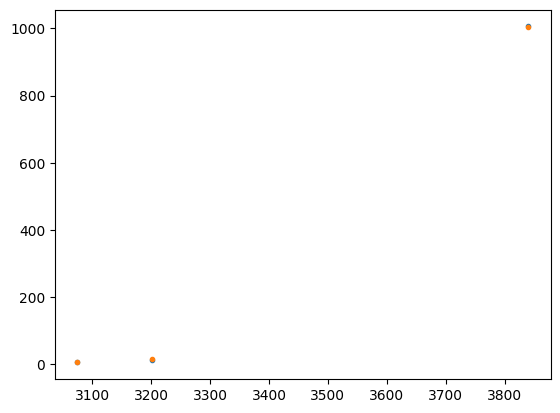

In [140]:
fig, ax = plt.subplots()
ax.plot(counter_idle.keys(), counts_idle.values(), '.', label="Idle")
ax.plot(counter_no_idle.keys(), counts_no_idle.values(), '.', label="No idle")